# S2 Inter-Rater Agreement — Free-Text Questions

Measures semantic agreement between all pairs of raters (human participants + models)
on free-text VQA answers using SBERT cosine similarity.

**Three comparisons (all free-text, inst_blind):**
- **HH** Human × Human — inter-participant agreement
- **MM** Model × Model — inter-model agreement
- **HM** Human × Model — cross-group agreement

**Yes/No questions are handled separately in `10b_align_agreement_yesno.ipynb`.**

In [9]:
# ── Metric configuration ──────────────────────────────────────────────────────
# All comparisons use English answers through the same VQA normalization pipeline.
#
# EMBEDDING_MODELS: metric_name → HuggingFace model ID
#   Each model encodes all unique answers once, cached as embeddings_{name}.npz.
#   Cosine similarity is computed from stored vectors — no re-encoding per run.
#
# Model notes:
#   sbert    all-mpnet-base-v2            strong baseline, mean-pooling
#   simcse   sup-simcse-roberta-large     contrastive STS training, best for short text
#
# BERTSCORE_MODEL: separate token-level F1 — does NOT use the embedding cache.
#   roberta-large (default) or microsoft/deberta-xlarge-mnli (slower, better)

EMBEDDING_MODELS = {
    'sbert':  'sentence-transformers/all-mpnet-base-v2',
    'simcse': 'princeton-nlp/sup-simcse-roberta-large',
}
BERTSCORE_MODEL = 'roberta-large'
HF_CACHE        = '/home/david/Desktop/yuna/.cache/hf'

# METHODS drives which metrics are computed. Embedding model keys are auto-included.
METHODS = ['exact', 'jaccard', 'rouge1', 'chrf', *EMBEDDING_MODELS.keys(), 'bertscore']

In [10]:
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

BASE    = Path('/home/david/Desktop/yuna/HPA')
EXPORTS = BASE / 'analysis/session2/exports'
sys.path.insert(0, str(BASE / 'analysis'))

from utils.constants import VARIANT_ORDER, VARIANT_LABELS, VARIANT_COLORS, GROUP_COLORS

In [11]:
# ── Load human data from nb09 export ─────────────────────────────────────────
from utils.vqa import VQAAnswerMapper

h_csv = pd.read_csv(EXPORTS / 'responses_human.csv')
h_csv['answer_en'] = h_csv['response']   # compatibility alias
df           = h_csv.copy()
common_qids  = set(df['question_id'].unique())
mapper       = VQAAnswerMapper()
print(f'Human data: {df["participant"].nunique()} participants, {len(common_qids)} questions')

Human data: 36 participants, 113 questions


In [12]:
# ── Load answer_type annotation from s4 ──────────────────────────────────────
q_meta = json.load(open(BASE / 'experiment/s2_v4/s4_question.json'))
answer_type_map = {q['question_id']: q['answer_type'] for q in q_meta}

# Add to df
df['answer_type'] = df['question_id'].map(answer_type_map)

# Split common_qids by type
yesno_qids = {qid for qid in common_qids if answer_type_map.get(qid) == 'yesno'}
text_qids  = {qid for qid in common_qids if answer_type_map.get(qid) == 'text'}
print(f'common_qids: {len(common_qids)} total — {len(yesno_qids)} yesno, {len(text_qids)} free-text')


common_qids: 113 total — 25 yesno, 88 free-text


In [13]:
# ── Load model results from nb09 export ──────────────────────────────────────
from utils.model_registry import default_all_models

m_csv = pd.read_csv(EXPORTS / 'responses_model_inst_blind.csv')

model_q_acc = {}
for label, grp in m_csv.groupby('model'):
    pivot = grp.pivot_table(index='question_id', columns='variant',
                             values='accuracy', aggfunc='mean')
    for var in VARIANT_ORDER:
        if var not in pivot.columns:
            pivot[var] = np.nan
    model_q_acc[label] = pivot[VARIANT_ORDER]

MODEL_TYPE = (m_csv[['model', 'model_group']].drop_duplicates()
              .set_index('model')['model_group'].to_dict())
ALL_MODELS = default_all_models(BASE)
MODELS     = {label: rdir / mdir for label, (rdir, mdir) in ALL_MODELS.items()}
print('Models:', list(model_q_acc.keys()))

Models: ['InternVL-1B', 'InternVL-2B', 'InternVL-8B', 'LLaVA-1.5 (LM)', 'LLaVA-1.5-7B', 'LLaVA-Mistral', 'LLaVA-Mistral (LM)', 'LLaVA-Vicuna', 'LLaVA-Vicuna (LM)', 'Mistral-7B', 'Phi-3.5-mini', 'Qwen2.5-7B', 'Qwen3-0.6B', 'Qwen3-0.6B (think)', 'Qwen3-1.7B', 'Qwen3-1.7B (think)', 'Qwen3-32B', 'Qwen3-32B (think)', 'Qwen3-4B', 'Qwen3-4B (think)', 'Qwen3-8B', 'Qwen3-8B (think)', 'Qwen3-VL-8B', 'Vicuna-13B']


In [14]:
# ── Compute inter-participant agreement split by answer type ──────────────────
# Lexical metrics (exact/jaccard/rouge1/chrf) are fast — computed for all types.
# SBERT excluded for yes/no (binary labels too coarse for embedding similarity).
from utils.agreement import compute_question_agreement

LEX_METHODS  = [m for m in ('exact', 'jaccard', 'rouge1', 'chrf') if m in METHODS]
TEXT_METHODS = [m for m in (*LEX_METHODS, 'sbert') if m in METHODS]

agree    = {}    # full question set
agree_tx = {}    # free-text only
agree_yn = {}    # yes/no only (lexical)

for var in VARIANT_ORDER:
    print(f'\n── Variant {var} ──')
    agree[var] = compute_question_agreement(
        df, common_qids,
        methods=TEXT_METHODS,
        answer_col='answer_en', variant=var, verbose=False,
    )
    agree_tx[var] = compute_question_agreement(
        df, text_qids,
        methods=TEXT_METHODS,
        answer_col='answer_en', variant=var, verbose=False,
    )
    agree_yn[var] = compute_question_agreement(
        df, yesno_qids,
        methods=LEX_METHODS,
        answer_col='answer_en', variant=var, verbose=False,
    )
    parts = [f'{m}={agree_tx[var][m].mean():.3f}' for m in TEXT_METHODS if m in agree_tx[var]]
    print(f'  [text  {len(text_qids):3d}q] ' + '  '.join(parts))
    yn_parts = [f'{m}={agree_yn[var][m].mean():.3f}' for m in LEX_METHODS if m in agree_yn[var]]
    print(f'  [yesno {len(yesno_qids):3d}q] ' + '  '.join(yn_parts))


── Variant C ──


  [text   88q] exact=0.130  jaccard=0.146  rouge1=0.153  chrf=0.191  sbert=0.513
  [yesno  25q] exact=0.580  jaccard=0.580  rouge1=0.580  chrf=0.580

── Variant B ──
  [text   88q] exact=0.118  jaccard=0.128  rouge1=0.132  chrf=0.172  sbert=0.488
  [yesno  25q] exact=0.600  jaccard=0.600  rouge1=0.600  chrf=0.600

── Variant A ──
  [text   88q] exact=0.103  jaccard=0.110  rouge1=0.113  chrf=0.153  sbert=0.469
  [yesno  25q] exact=0.554  jaccard=0.554  rouge1=0.554  chrf=0.554


/tmp/ipykernel_451601/1433733580.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
/tmp/ipykernel_451601/1433733580.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],


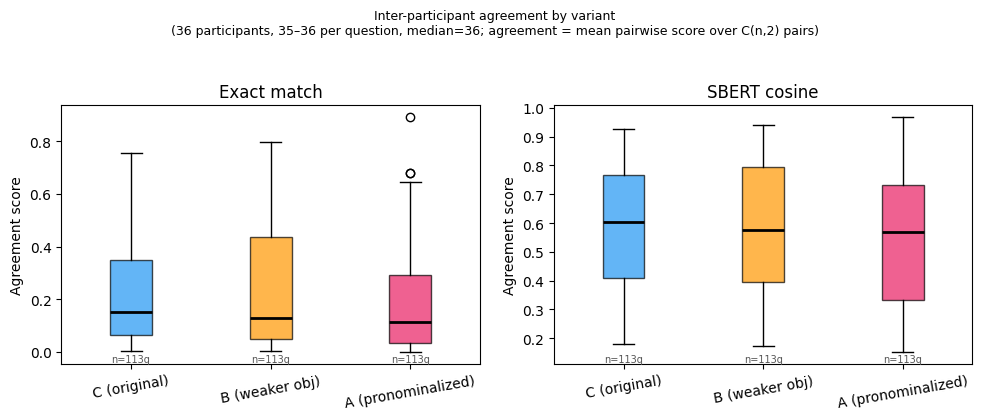

n (qids)   Mean  Median    Std    Q25    Q75
Variant Metric                                                    
C       Exact match        113  0.230   0.151  0.213  0.065  0.349
        SBERT cosine       113  0.593   0.604  0.211  0.410  0.767
B       Exact match        113  0.224   0.127  0.232  0.049  0.435
        SBERT cosine       113  0.575   0.576  0.223  0.395  0.795
A       Exact match        113  0.202   0.114  0.213  0.035  0.290
        SBERT cosine       113  0.557   0.570  0.230  0.332  0.733

In [15]:
# ── Agreement by variant — box plots ─────────────────────────────────────────
# n per question = number of participants answering that question in variant C
# Agreement score = mean pairwise [metric] over all C(n,2) pairs of participants
# Box shows distribution across all common questions (text+yesno combined)

per_q_n = df[df['variant'] == 'C'].groupby('question_id')['answer_en'].count()
n_min, n_max, n_med = int(per_q_n.min()), int(per_q_n.max()), int(per_q_n.median())

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
methods = [('exact', 'Exact match'), ('sbert', 'SBERT cosine')]
colors  = {'C': '#2196F3', 'B': '#FF9800', 'A': '#E91E63'}

for ax, (meth, title) in zip(axes, methods):
    data = [agree[var][meth].dropna().values for var in VARIANT_ORDER]
    ns   = [len(d) for d in data]
    bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
                    patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, var in zip(bp['boxes'], VARIANT_ORDER):
        patch.set_facecolor(colors[var])
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel('Agreement score')
    ax.tick_params(axis='x', rotation=10)
    for i, (var, n_q) in enumerate(zip(VARIANT_ORDER, ns), 1):
        ax.text(i, ax.get_ylim()[0], f'n={n_q}q', ha='center', va='bottom',
                fontsize=7, color='#555')

n_participants = df['participant'].nunique()
plt.suptitle(
    f'Inter-participant agreement by variant\n'
    f'({n_participants} participants, {n_min}–{n_max} per question, median={n_med}; '
    f'agreement = mean pairwise score over C(n,2) pairs)',
    y=1.04, fontsize=9
)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for var in VARIANT_ORDER:
    for meth, meth_label in methods:
        vals = agree[var][meth].dropna()
        rows.append({
            'Variant':  var,
            'Metric':   meth_label,
            'n (qids)': len(vals),
            'Mean':     round(vals.mean(), 3),
            'Median':   round(vals.median(), 3),
            'Std':      round(vals.std(), 3),
            'Q25':      round(vals.quantile(0.25), 3),
            'Q75':      round(vals.quantile(0.75), 3),
        })
        

summary_df = pd.DataFrame(rows).set_index(['Variant', 'Metric'])
display(summary_df)

Pearson r — metric agreement vs human accuracy (free-text, variant C):
  [exact    var=C]  r=0.698  p=0.000  n=88
  [exact    var=B]  r=0.785  p=0.000  n=88
  [exact    var=A]  r=0.713  p=0.000  n=88
  [jaccard  var=C]  r=0.628  p=0.000  n=88
  [jaccard  var=B]  r=0.766  p=0.000  n=88
  [jaccard  var=A]  r=0.708  p=0.000  n=88
  [rouge1   var=C]  r=0.589  p=0.000  n=88
  [rouge1   var=B]  r=0.755  p=0.000  n=88
  [rouge1   var=A]  r=0.702  p=0.000  n=88
  [chrf     var=C]  r=0.577  p=0.000  n=88
  [chrf     var=B]  r=0.733  p=0.000  n=88
  [chrf     var=A]  r=0.639  p=0.000  n=88
  [sbert    var=C]  r=0.518  p=0.000  n=88
  [sbert    var=B]  r=0.576  p=0.000  n=88
  [sbert    var=A]  r=0.555  p=0.000  n=88


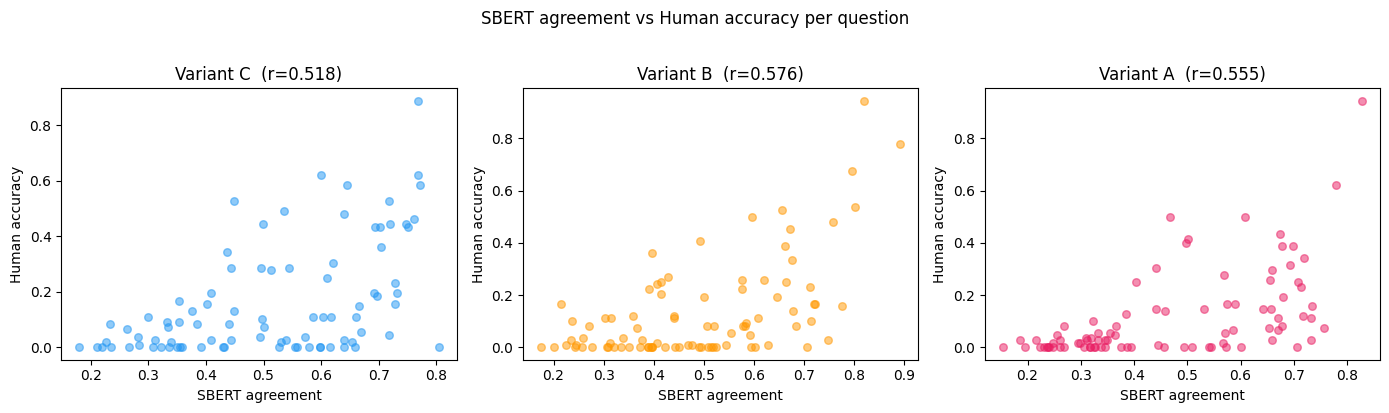

In [16]:
# ── Correlation: agreement vs human accuracy ──────────────────────────────────
h_acc = df.groupby(['question_id', 'variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]

print('Pearson r — metric agreement vs human accuracy (free-text, variant C):')
for m in TEXT_METHODS:
    for var in VARIANT_ORDER:
        if m not in agree_tx[var]: continue
        merged = agree_tx[var][[m]].join(h_acc[[var]].rename(columns={var: 'acc'})).dropna()
        if len(merged) < 2: continue
        r, p = pearsonr(merged[m], merged['acc'])
        print(f'  [{m:8s} var={var}]  r={r:.3f}  p={p:.3f}  n={len(merged)}')

# Scatter: SBERT agreement vs accuracy, one panel per variant
if 'sbert' in TEXT_METHODS:
    from utils.constants import VARIANT_COLORS
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, var in zip(axes, VARIANT_ORDER):
        merged = agree_tx[var][['sbert']].join(
            h_acc[[var]].rename(columns={var: 'acc'})).dropna()
        ax.scatter(merged['sbert'], merged['acc'], alpha=0.5,
                   color=VARIANT_COLORS.get(var, '#888'), s=30)
        r, _ = pearsonr(merged['sbert'], merged['acc'])
        ax.set_xlabel('SBERT agreement')
        ax.set_ylabel('Human accuracy')
        ax.set_title(f'Variant {var}  (r={r:.3f})')
    plt.suptitle('SBERT agreement vs Human accuracy per question', y=1.02)
    plt.tight_layout()
    plt.show()

Pearson r — SBERT agreement vs human accuracy:
  [All]  metric=sbert
    Variant C: r=0.688  p=0.000  n=113 questions
    Variant B: r=0.684  p=0.000  n=113 questions
    Variant A: r=0.741  p=0.000  n=113 questions
  [Yesno]  metric=exact (SBERT N/A)
    Variant C: r=0.172  p=0.410  n=25 questions
    Variant B: r=-0.250  p=0.229  n=25 questions
    Variant A: r=0.294  p=0.154  n=25 questions
  [Text]  metric=sbert
    Variant C: r=0.518  p=0.000  n=88 questions
    Variant B: r=0.576  p=0.000  n=88 questions
    Variant A: r=0.555  p=0.000  n=88 questions


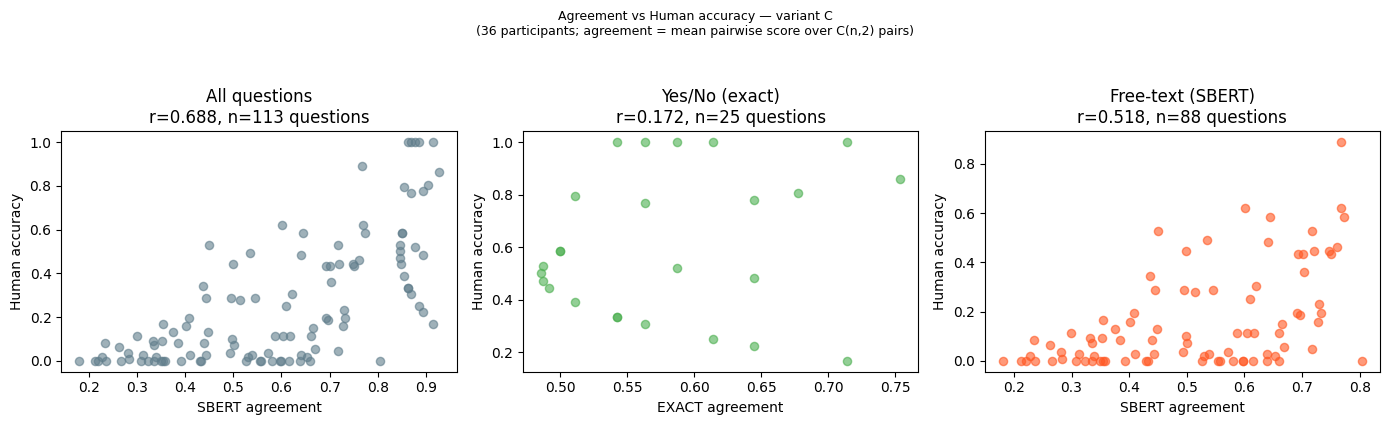

In [17]:
# ── Correlation: agreement vs human accuracy — by answer type ─────────────────
# n shown per scatter point = questions; participants per question shown in title
h_acc = df.groupby(['question_id', 'variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]

print('Pearson r — SBERT agreement vs human accuracy:')
for label, ag_dict, qids, avail_metrics in [
        ('All',   agree,    common_qids, ['sbert']),
        ('Yesno', agree_yn, yesno_qids,  ['exact']),   # no SBERT for yesno
        ('Text',  agree_tx, text_qids,   ['sbert'])]:
    print(f'  [{label}]  metric={"sbert" if "sbert" in avail_metrics else "exact (SBERT N/A)"}')
    metric = avail_metrics[0]
    for var in VARIANT_ORDER:
        merged = ag_dict[var][[metric]].join(h_acc[[var]].rename(columns={var:'acc'})).dropna()
        if len(merged) < 3:
            print(f'    Variant {var}: n={len(merged)} (too few)')
            continue
        r, p = pearsonr(merged[metric], merged['acc'])
        print(f'    Variant {var}: r={r:.3f}  p={p:.3f}  n={len(merged)} questions')

# ── Scatter variant C: All / Yesno (exact) / Text (sbert) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_cfg = [
    ('All questions',  agree,    'sbert', '#607D8B'),
    ('Yes/No (exact)', agree_yn, 'exact', '#4CAF50'),
    ('Free-text (SBERT)', agree_tx, 'sbert', '#FF5722'),
]
for ax, (label, ag_dict, metric, color) in zip(axes, plot_cfg):
    merged = ag_dict['C'][[metric]].join(h_acc[['C']].rename(columns={'C':'acc'})).dropna()
    n_q = len(merged)
    ax.scatter(merged[metric], merged['acc'], alpha=0.6, color=color, s=35)
    if n_q >= 3:
        r, _ = pearsonr(merged[metric], merged['acc'])
        ax.set_title(f'{label}\nr={r:.3f}, n={n_q} questions')
    ax.set_xlabel(f'{metric.upper()} agreement')
    ax.set_ylabel('Human accuracy')

n_participants = df['participant'].nunique()
plt.suptitle(
    f'Agreement vs Human accuracy — variant C\n'
    f'({n_participants} participants; agreement = mean pairwise score over C(n,2) pairs)',
    y=1.05, fontsize=9
)
plt.tight_layout()
plt.show()

Agreement by entity type (variant C, sorted by primary metric):
         sbert  exact  jaccard  rouge1   N
ent                                       
food     0.657  0.277    0.293   0.300  16
animal   0.629  0.254    0.269   0.275  17
place    0.617  0.294    0.298   0.300   5
object   0.598  0.221    0.230   0.234  27
product  0.572  0.147    0.160   0.166   5
person   0.567  0.232    0.245   0.251  26
vehicle  0.549  0.272    0.292   0.301   4
other    0.544  0.178    0.193   0.199   9
text     0.458  0.082    0.085   0.086   4


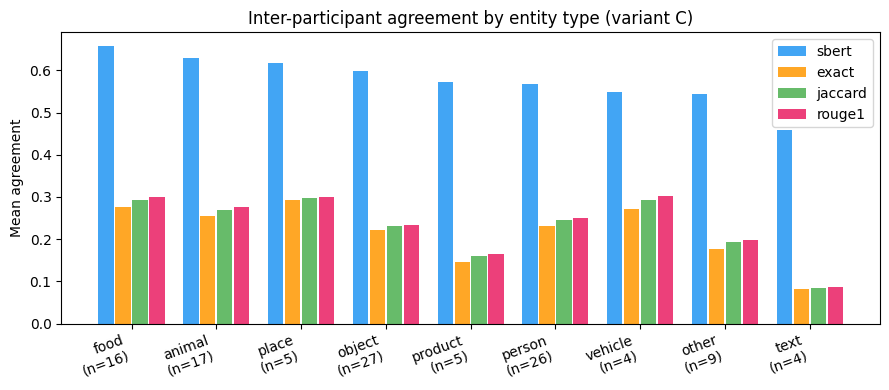

In [18]:
# ── Agreement by entity type ──────────────────────────────────────────────────
ent_map = df[['question_id', 'ent']].drop_duplicates().set_index('question_id')['ent']

# Use metrics that were computed for the full question set
plot_metrics = [m for m in ('sbert', 'exact', 'jaccard', 'rouge1') if m in agree['C'].columns]
ent_agree = agree['C'][plot_metrics].join(ent_map).groupby('ent').mean()
ent_n     = agree['C'][plot_metrics[:1]].join(ent_map).groupby('ent')[plot_metrics[0]].count().rename('N')
ent_table = ent_agree.join(ent_n).sort_values(plot_metrics[0], ascending=False)

print('Agreement by entity type (variant C, sorted by primary metric):')
print(ent_table.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(ent_table))
w = 0.8 / max(len(plot_metrics), 1)
colors_m = {'sbert': '#2196F3', 'exact': '#FF9800', 'jaccard': '#4CAF50', 'rouge1': '#E91E63'}
for k, m in enumerate(plot_metrics):
    offset = (k - len(plot_metrics) / 2 + 0.5) * w
    ax.bar(x + offset, ent_table[m], w * 0.9, label=m, alpha=0.85,
           color=colors_m.get(m, '#888'))
ax.set_xticks(x)
ax.set_xticklabels([f'{e}\n(n={ent_table.loc[e,"N"]})' for e in ent_table.index],
                   rotation=20, ha='right')
ax.set_ylabel('Mean agreement')
ax.set_title('Inter-participant agreement by entity type (variant C)')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# ── Top / bottom agreed FREE-TEXT questions (SBERT, variant C) ────────────────
# n = number of participants per question who answered in variant C
# agreement = mean pairwise SBERT cosine over all C(n,2) pairs

q_en_map = {}
for _, row in df[df['variant'] == 'C'].drop_duplicates('question_id').iterrows():
    q_en_map[row['question_id']] = row.get('question_en', str(row['question_id']))

N = 8
tx_sbert = agree_tx['C']['sbert'].dropna()

for label, ascending in [('LOWEST agreement', True), ('HIGHEST agreement', False)]:
    top = tx_sbert.sort_values(ascending=ascending).head(N)
    print(f'\n── {label} — free-text only (SBERT, variant C) ──')
    for qid, score in top.items():
        answers = df[(df.question_id == qid) & (df.variant == 'C')]['answer_en'].dropna().tolist()
        n = len(answers)
        unique  = sorted(set(answers))
        print(f'  [{score:.3f}, n={n} participants, {len(unique)} unique] {q_en_map.get(qid, qid)}')
        print(f'    answers: {unique[:6]}')


── LOWEST agreement — free-text only (SBERT, variant C) ──
  [0.180, n=36 participants, 35 unique] What kind of information does the yellow and white book look like it contains?
    answers: ['0', '4 pillars of destiny', 'anatomy information', 'book', 'cooking', 'egg']
  [0.212, n=36 participants, 33 unique] What does the man's gesture mean?
    answers: ['0', '1 more please', 'accepts', 'agreement', 'anger', 'be quiet']
  [0.220, n=36 participants, 29 unique] What does the shirt say?
    answers: ['0', '1', '3', 'adidas', 'aot', 'bac']
  [0.227, n=36 participants, 30 unique] What might a milkman have in common with the man with the backpack?
    answers: ['backpack', 'both are carrying bags', 'both are men', 'bought shares of cosmo chemical', 'carrying bag', 'carrying luggage']
  [0.234, n=36 participants, 29 unique] What does the mile say?
    answers: ['0', '10', '100', '104', '30', '40']
  [0.236, n=36 participants, 33 unique] What letter is yellow and white?
    answers: ['0', 'a

In [20]:
# ── q_en_map: question_id → English question text (variant C) ───────────────
if 'q_en_map' not in dir():
    q_en_map = {row['question_id']: row.get('question_en', str(row['question_id']))
                for _, row in df[df['variant'] == 'C'].drop_duplicates('question_id').iterrows()}


def _yn_norm(text):
    t = str(text).strip().lower()
    if t.startswith('yes'):
        return 'yes'
    if t.startswith('no'):
        return 'no'
    return t

# ── Top / bottom agreed YES/NO questions (exact match, variant C) ────────────
# For yes/no questions, exact match is used; SBERT is excluded (trivial token embeddings).
# Agreement = fraction of all C(n,2) participant pairs with identical answers.
# Sorted from least agreed (most split) → most agreed (strong consensus).

yn_sbert_excluded_note = '(SBERT excluded — binary token embeddings are uninformative)'

yn_exact = agree_yn['C']['exact'].dropna()
N = 8

for label, ascending in [('MOST SPLIT (lowest exact-match agreement)', True),
                         ('MOST CONSENSUS (highest exact-match agreement)', False)]:
    top = yn_exact.sort_values(ascending=ascending).head(N)
    print(f'\n── {label} — yes/no only (variant C) {yn_sbert_excluded_note} ──')
    for qid, score in top.items():
        answers = df[(df.question_id == qid) & (df.variant == 'C')]['answer_en'].dropna().tolist()
        n = len(answers)
        yn_answers = [_yn_norm(a) for a in answers]
        yes_n = yn_answers.count('yes')
        no_n  = yn_answers.count('no')
        other = n - yes_n - no_n
        other_str = f', {other} other' if other else ''
        print(f'  [exact={score:.3f}, n={n}] {q_en_map.get(qid, qid)}')
        print(f'    yes={yes_n}, no={no_n}{other_str}')



── MOST SPLIT (lowest exact-match agreement) — yes/no only (variant C) (SBERT excluded — binary token embeddings are uninformative) ──
  [exact=0.486, n=36] Are the elephants sleeping?
    yes=18, no=18
  [exact=0.487, n=36] Is there a lighthouse?
    yes=19, no=17
  [exact=0.487, n=36] Is the woman's top sleeveless?
    yes=19, no=17
  [exact=0.492, n=36] Is the water in the bathtub turned on?
    yes=20, no=16
  [exact=0.500, n=36] Is the girl wearing motorbike boots?
    yes=15, no=21
  [exact=0.500, n=36] Are the cats ready to attack?
    yes=15, no=21
  [exact=0.511, n=36] Are the sheep all standing in a row?
    yes=22, no=14
  [exact=0.511, n=36] Is the toilet open?
    yes=22, no=14

── MOST CONSENSUS (highest exact-match agreement) — yes/no only (variant C) (SBERT excluded — binary token embeddings are uninformative) ──
  [exact=0.754, n=36] Is this car clean?
    yes=31, no=5
  [exact=0.714, n=36] Are these women friends?
    yes=30, no=6
  [exact=0.714, n=36] Is the girl lo

In [21]:
# ── Question text lookups (en + kr) ─────────────────────────────────────────
q_meta_list = json.load(open(BASE / 'experiment/s2_v4/s4_question.json'))
q_en  = {q['question_id']: q['question_en'] for q in q_meta_list}
q_kr  = {q['question_id']: q['question_kr'] for q in q_meta_list}

# Variant-aware lookup (weaker_object / pronominalized JSONs have their own text)
_wb = json.load(open(BASE / 'experiment/s2_v4/s4_weaker_object.json'))
_pr = json.load(open(BASE / 'experiment/s2_v4/s4_pronominalized.json'))
q_en_var = {}  # (qid, var) → question_en
q_kr_var = {}
for entry, var in [(_wb, 'B'), (_pr, 'A')]:
    for q in entry:
        q_en_var[(q['question_id'], var)] = q.get('question_en', q_en.get(q['question_id'], ''))
        q_kr_var[(q['question_id'], var)] = q.get('question_kr', q_kr.get(q['question_id'], ''))
for qid in common_qids:
    q_en_var[(qid, 'C')] = q_en.get(qid, '')
    q_kr_var[(qid, 'C')] = q_kr.get(qid, '')

print(f"Question text loaded for {len(q_en)} questions")

Question text loaded for 134 questions


## HH / MM / HM Agreement — Free-Text Questions

In [22]:
# ── Load embedding models ─────────────────────────────────────────────────────
# Each model in EMBEDDING_MODELS is loaded once, then encode_with_cache() is used
# to encode answers and persist vectors in exports/embeddings_{name}.npz.
# On re-run, only new answers are encoded; everything else is loaded from disk.

from sentence_transformers import SentenceTransformer
from utils.agreement import (_pair_exact, _pair_jaccard, _pair_rouge1, _pair_chrf,
                              bertscore_batch, encode_with_cache)

# ── Build rater answer dicts from nb09 exports ────────────────────────────────
rater_answers = {}
rater_group   = {}

for _, row in h_csv[h_csv['question_id'].isin(text_qids)].iterrows():
    pid    = row['participant']
    qid    = int(row['question_id'])
    var    = row['variant']
    ans_en = str(row['response'] or '').strip()
    if not ans_en:
        continue
    if pid not in rater_answers:
        rater_answers[pid] = {}
        rater_group[pid]   = 'human'
    rater_answers[pid][(qid, var)] = ans_en

for _, row in m_csv[m_csv['question_id'].isin(text_qids)].iterrows():
    label = row['model']
    qid   = int(row['question_id'])
    var   = row['variant']
    ans   = str(row['response'] or '').strip()
    if not ans:
        continue
    if label not in rater_answers:
        rater_answers[label] = {}
        rater_group[label]   = row['model_group']
    rater_answers[label][(qid, var)] = ans

all_raters   = list(rater_answers.keys())
human_raters = [r for r in all_raters if rater_group[r] == 'human']
model_raters = [r for r in all_raters if rater_group[r] != 'human']
print(f'Raters: {len(human_raters)} humans + {len(model_raters)} models = {len(all_raters)} total')

# ── Question metadata ─────────────────────────────────────────────────────────
q_ent = df[['question_id', 'ent']].drop_duplicates().set_index('question_id')['ent'].to_dict()
q_op  = df[['question_id', 'op']].drop_duplicates().set_index('question_id')['op'].to_dict()

# ── Encode answers with each model, loading from cache where possible ─────────
all_answers_en = sorted({a for r in all_raters for a in rater_answers[r].values()})
print(f'Unique EN answers to embed: {len(all_answers_en)}')

emb_caches = {}   # metric_name → {answer: L2-normalised float32 vector}
for metric_name, model_id in EMBEDDING_MODELS.items():
    if metric_name not in METHODS:
        continue
    tag        = model_id.split('/')[-1]
    cache_path = EXPORTS / f'embeddings_{tag}.npz'
    model      = SentenceTransformer(model_id, cache_folder=HF_CACHE)
    emb_caches[metric_name] = encode_with_cache(all_answers_en, model, cache_path)
    print(f'  [{metric_name}] {tag}: {len(emb_caches[metric_name])} vectors cached')

# Primary embedding dict (first model) — used for filtering in pair loop
_primary_emb = next(iter(emb_caches.values())) if emb_caches else {}
print('Embeddings ready.')

ImportError: cannot import name 'encode_with_cache' from 'utils.agreement' (/home/david/Desktop/yuna/HPA/analysis/utils/agreement.py)

In [23]:
# ── Incremental cache — load previously computed scores ──────────────────────
# pair_cache.parquet stores one row per (subject_1, subject_2, question_id, variant)
# with all metric columns. On re-run we skip pairs that are already scored.
#
# To recompute everything from scratch, delete the file:
#   rm analysis/session2/exports/pair_cache.parquet

CACHE_PATH = EXPORTS / 'pair_cache.parquet'

cache_df     = None
cached_keys  = set()

if CACHE_PATH.exists():
    cache_df = pd.read_parquet(CACHE_PATH)
    cached_keys = set(
        zip(cache_df['subject_1'], cache_df['subject_2'],
            cache_df['question_id'], cache_df['variant'])
    )
    print(f'Cache loaded: {len(cache_df):,} pairs already scored '
          f'({cache_df["variant"].value_counts().to_dict()})')
    print(f'Metrics in cache: {[c for c in cache_df.columns if c.endswith("_score") or c.endswith("_clip") or c == "bertscore_f1"]}')
else:
    print('No cache found — will compute all pairs from scratch')

No cache found — will compute all pairs from scratch


In [24]:
# ── Build pair-level and question-level agreement tables (free-text) ──────────
# Lexical metrics: exact / jaccard / rouge1 / chrf
# Embedding cosine: one score per model in EMBEDDING_MODELS (clipped to [0,1])
# Token-level F1:   bertscore (computed as a batch in the next cell)
from itertools import combinations
from utils.agreement import _pair_exact, _pair_jaccard, _pair_rouge1, _pair_chrf, bertscore_batch

_lex_metrics = [m for m in ('exact', 'jaccard', 'rouge1', 'chrf') if m in METHODS]
_emb_metrics = [m for m in EMBEDDING_MODELS if m in METHODS]
_all_metrics = _lex_metrics + _emb_metrics

pair_rows     = []
question_rows = []

for var in VARIANT_ORDER:
    for qid in sorted(text_qids):
        q_answers = {r: rater_answers[r].get((qid, var)) for r in all_raters}
        q_answers = {r: a for r, a in q_answers.items() if a and a in _primary_emb}
        present   = list(q_answers.keys())
        if len(present) < 2:
            continue

        present_h = [r for r in present if rater_group[r] == 'human']
        present_m = [r for r in present if rater_group[r] != 'human']
        q_en_text = q_en_var.get((qid, var), q_en.get(qid, ''))
        q_kr_text = q_kr_var.get((qid, var), q_kr.get(qid, ''))

        type_scores = {pt: {m: [] for m in _all_metrics} for pt in ('HH', 'MM', 'HM')}

        for r1, r2 in combinations(present, 2):
            key = (min(r1, r2), max(r1, r2), qid, var)
            if key in cached_keys:
                continue
            g1, g2 = rater_group[r1], rater_group[r2]
            if   g1 == 'human' and g2 == 'human': ptype = 'HH'
            elif g1 != 'human' and g2 != 'human': ptype = 'MM'
            else:
                ptype = 'HM'
                if g1 != 'human':
                    r1, r2 = r2, r1
                    g1, g2 = g2, g1

            en1, en2 = q_answers[r1], q_answers[r2]

            scores = {}
            if 'exact'   in METHODS: scores['exact']   = _pair_exact(en1, en2)
            if 'jaccard' in METHODS: scores['jaccard']  = _pair_jaccard(en1, en2)
            if 'rouge1'  in METHODS: scores['rouge1']   = _pair_rouge1(en1, en2)
            if 'chrf'    in METHODS: scores['chrf']     = _pair_chrf(en1, en2)
            for em in _emb_metrics:
                v = float(np.dot(emb_caches[em][en1], emb_caches[em][en2]))
                scores[em]        = v
                scores[em + '_c'] = max(v, 0.0)

            for mk in _all_metrics:
                stored = scores.get(mk + '_c' if mk in _emb_metrics else mk)
                if stored is not None:
                    type_scores[ptype][mk].append(stored)

            pair_rows.append({
                'question_id':     qid,
                'question_en':     q_en_text,
                'question_kr':     q_kr_text,
                'variant':         var,
                'ent':             q_ent.get(qid, ''),
                'op':              q_op.get(qid, ''),
                'pair_type':       ptype,
                'subject_group_1': g1,
                'subject_1':       r1,
                'subject_group_2': g2,
                'subject_2':       r2,
                'answer_1':        en1,
                'answer_2':        en2,
                **{f'{m}_score':      round(scores[m],     4) for m in _lex_metrics if m in scores},
                **{f'{m}_score':      round(scores[m],     4) for m in _emb_metrics if m in scores},
                **{f'{m}_score_clip': round(scores[m+"_c"], 4) for m in _emb_metrics if m+"_c" in scores},
            })

        def _mean(lst): return float(np.mean(lst)) if lst else float('nan')
        question_rows.append({
            'question_id': qid,
            'question_en': q_en_text,
            'question_kr': q_kr_text,
            'variant':     var,
            'ent':         q_ent.get(qid, ''),
            'op':          q_op.get(qid, ''),
            'n_raters':    len(present),
            'n_humans':    len(present_h),
            'n_models':    len(present_m),
            **{f'n_pairs_{pt}': len(type_scores[pt][_all_metrics[0]])
               for pt in ('HH', 'MM', 'HM')},
            **{f'{pt}_{m}': _mean(type_scores[pt][m])
               for pt in ('HH', 'MM', 'HM') for m in _all_metrics},
        })

pairs_df         = pd.DataFrame(pair_rows)
question_pair_df = pd.DataFrame(question_rows)

print(f'Total new pairs: {len(pairs_df):,}')
if not pairs_df.empty:
    C_pairs = pairs_df[pairs_df.variant == 'C']
    score_cols = [c for c in pairs_df.columns if c.endswith('_score') or c.endswith('_clip')]
    print('\nMean scores by pair type (variant C, new pairs only):')
    for col in score_cols:
        row = C_pairs.groupby('pair_type')[col].mean().reindex(['HH', 'MM', 'HM'])
        print(f'  {col:28s}  HH={row.get("HH", float("nan")):.3f}  '
              f'MM={row.get("MM", float("nan")):.3f}  HM={row.get("HM", float("nan")):.3f}')

SyntaxError: '(' was never closed (2012392617.py, line 59)

In [25]:
# ── BERTScore batch computation ───────────────────────────────────────────────
# Runs only if 'bertscore' in METHODS.
# Skips pairs already scored in cache. Saves after computing.

if 'bertscore' in METHODS:
    import torch
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Only compute for NEW pairs (not in cache)
    new_pairs_df = pd.DataFrame(pair_rows) if pair_rows else pd.DataFrame()
    bs_todo = new_pairs_df[~new_pairs_df.get('bertscore_f1', pd.Series(dtype=float)).notna()]         if not new_pairs_df.empty and 'bertscore_f1' in new_pairs_df.columns         else new_pairs_df

    if bs_todo.empty:
        print('BERTScore: all pairs already cached, nothing to compute.')
    else:
        print(f'Computing BERTScore ({BERTSCORE_MODEL}) on {device} '
              f'for {len(bs_todo):,} pairs …')
        cands     = bs_todo['answer_1'].tolist()
        refs      = bs_todo['answer_2'].tolist()
        f1_scores = bertscore_batch(cands, refs,
                                    model_type=BERTSCORE_MODEL,
                                    device=device,
                                    batch_size=128,
                                    verbose=True)
        new_pairs_df.loc[bs_todo.index, 'bertscore_f1'] = f1_scores.round(4)

    # Rebuild pair_rows from updated df so the export cell picks it up
    pair_rows = new_pairs_df.to_dict('records')

    # Preview
    if not new_pairs_df.empty and 'bertscore_f1' in new_pairs_df.columns:
        C_new = new_pairs_df[new_pairs_df.get('variant', '') == 'C']
        if not C_new.empty:
            row = C_new.groupby('pair_type')['bertscore_f1'].mean().reindex(['HH','MM','HM'])
            print(f'\nBERTScore F1 (variant C, new pairs):')
            print(f'  HH={row.get("HH",float("nan")):.3f}  MM={row.get("MM",float("nan")):.3f}  HM={row.get("HM",float("nan")):.3f}')
else:
    print('BERTScore skipped (not in METHODS)')

NameError: name 'pair_rows' is not defined

NameError: name 'question_pair_df' is not defined

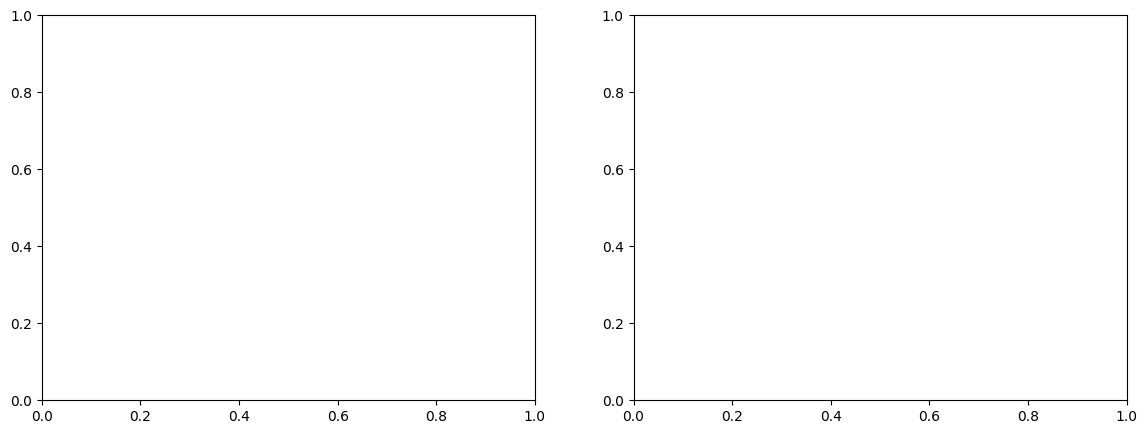

In [26]:
# ── Question-level agreement box plot: HH / MM / HM (free-text) ──────────────
from IPython.display import display

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution by pair type (variant C), one point per question
ax = axes[0]
C_q = question_pair_df[question_pair_df.variant == 'C']
data_by_type = [C_q[pt].dropna().values for pt in ['HH', 'MM', 'HM']]
colors_bt = ['#333333', '#9C27B0', '#FF5722']
bp = ax.boxplot(
    data_by_type,
    labels=['HH (human–human)', 'MM (model–model)', 'HM (human–model)'],
    patch_artist=True,
    medianprops=dict(color='white', lw=2),
)
for patch, c in zip(bp['boxes'], colors_bt):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
for i, vals in enumerate(data_by_type, 1):
    ax.text(i, ax.get_ylim()[0], f'n={len(vals):,} q', ha='center', va='bottom', fontsize=7, color='#555')
ax.set_ylabel('Clipped SBERT cosine similarity')
ax.set_title(
    f'Question-level agreement by pair type '
    f'(variant C, free-text, n={C_q["question_id"].nunique()} qids)'
)
ax.set_ylim(-0.05, 1.05)

# Right: per-variant trend for each pair type, question-level means
ax = axes[1]
x = np.arange(len(VARIANT_ORDER))
for pt, color in zip(['HH', 'MM', 'HM'], colors_bt):
    means = [question_pair_df[question_pair_df.variant == v][pt].mean() for v in VARIANT_ORDER]
    sems = [question_pair_df[question_pair_df.variant == v][pt].dropna().sem() for v in VARIANT_ORDER]
    ax.plot(x, means, 'o-', color=color, label=pt, lw=2, ms=7)
    ax.fill_between(
        x,
        np.array(means) - 1.96 * np.array(sems),
        np.array(means) + 1.96 * np.array(sems),
        color=color,
        alpha=0.12,
    )
ax.set_xticks(x)
ax.set_xticklabels(['C (original)', 'B (weaker obj)', 'A (pronominalized)'])
ax.set_ylabel('Mean clipped SBERT cosine')
ax.set_title('Question-level agreement trend C → B → A (free-text, clipped at 0, ±95% CI)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Inter-Rater Agreement — Free-Text Questions (inst_blind, clipped cosine)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
tbl_rows = []
for var in VARIANT_ORDER:
    sub = question_pair_df[question_pair_df.variant == var]
    for pt in ['HH', 'MM', 'HM']:
        vals = sub[pt].dropna()
        tbl_rows.append({
            'Variant': var,
            'Pair type': pt,
            'n questions': len(vals),
            'Mean': round(vals.mean(), 3),
            'Median': round(vals.median(), 3),
            'Std': round(vals.std(), 3),
        })
display(pd.DataFrame(tbl_rows).set_index(['Variant', 'Pair type']))


NameError: name 'model_summary_df' is not defined

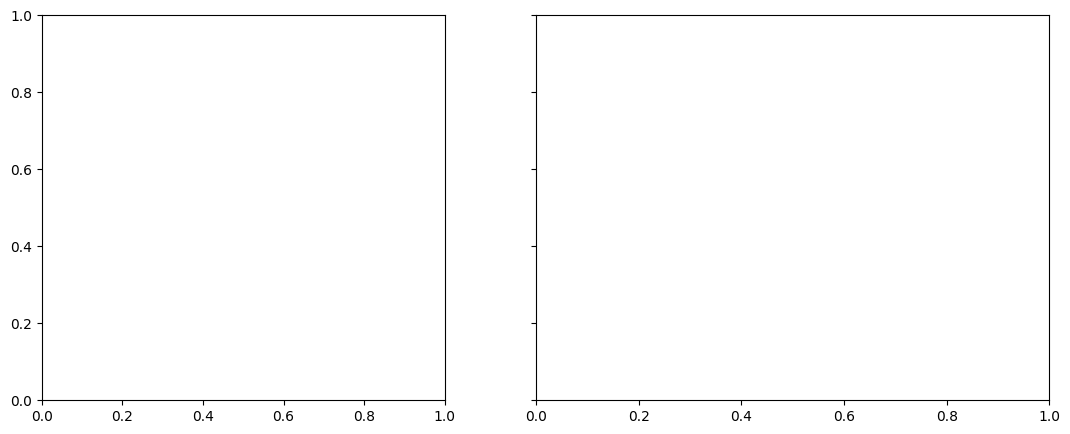

In [27]:
# ── Variant-separated model alignment distribution ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1.1, 1.4]}, sharey=True)

# Left: model-level distribution within each variant
ax = axes[0]
box_data = [
    model_summary_df[model_summary_df['variant'] == var]['hm_mean'].dropna().values
    for var in VARIANT_ORDER
]
bp = ax.boxplot(
    box_data,
    labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
)
for patch, var in zip(bp['boxes'], VARIANT_ORDER):
    patch.set_facecolor(VARIANT_COLORS[var])
    patch.set_alpha(0.55)
for i, var in enumerate(VARIANT_ORDER, 1):
    sub = model_summary_df[model_summary_df['variant'] == var]
    x = np.random.normal(i, 0.04, size=len(sub))
    colors = [GROUP_COLORS.get(g, '#888888') for g in sub['model_group']]
    ax.scatter(x, sub['hm_mean'], c=colors, s=40, alpha=0.9, edgecolor='white', linewidth=0.5)
    hh_var = float(hh_ref_df.loc[hh_ref_df['variant'] == var, 'hh_mean'].iloc[0])
    ax.hlines(hh_var, i - 0.28, i + 0.28, colors='red', linestyles='--', lw=2)
    # ax.text(i, 0.4, f'n={len(sub)} models', ha='center', va='bottom', fontsize=8, color='#555')
ax.set_ylabel('Mean clipped human–model cosine')
ax.set_title(f'Model-level alignment by variant\n(n={len(sub)} models)') # red dash = HH reference per variant)')
ax.set_ylim(0.2, 0.8)

# Right: grouped bars by model group across variants
ax = axes[1]
groups = list(TIER_ORDER)
x = np.arange(len(VARIANT_ORDER))
width = 0.22
for j, group in enumerate(groups):
    sub = group_summary_df[group_summary_df['model_group'] == group].set_index('variant').reindex(VARIANT_ORDER)
    vals = sub['hm_mean'].to_numpy()
    ax.bar(
        x + (j - 1) * width,
        vals,
        width=width,
        color=GROUP_COLORS.get(group, '#888888'),
        alpha=0.8,
        label=group,
    )
    for xi, yi in zip(x + (j - 1) * width, vals):
        if not np.isnan(yi):
            ax.text(xi, yi + 0.01, f'{yi:.2f}', ha='center', va='bottom', fontsize=7, rotation=90)
for i, var in enumerate(VARIANT_ORDER):
    hh_var = float(hh_ref_df.loc[hh_ref_df['variant'] == var, 'hh_mean'].iloc[0])
    ax.hlines(hh_var, i - 0.4, i + 0.4, colors='red', linestyles='--', lw=2)
ax.set_xticks(x)
ax.set_xticklabels([VARIANT_LABELS[v] for v in VARIANT_ORDER])
ax.set_ylim(0.3, 0.6)
ax.set_ylabel('Mean clipped human–model cosine')
ax.set_title('Model-group means by variant\n(red dash = HH reference)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Variant-Separated Human–Model Alignment (n_humans={n_humans_ref}; questions={n_questions_c})',
    y=1.02,
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [28]:
# ── Per-question HH vs HM rank plot (variant C) ─────────────────────────────
# Shows whether the human-model gap is broad or concentrated in a subset.
rank_df = (
    question_pair_df[question_pair_df['variant'] == 'C'][['question_id', 'question_en', 'HH', 'HM', 'MM']]
    .dropna(subset=['HH', 'HM'])
    .copy()
)
rank_df['gap_HH_HM'] = rank_df['HH'] - rank_df['HM']
rank_df = rank_df.sort_values('gap_HH_HM', ascending=False).reset_index(drop=True)
rank_df['rank'] = np.arange(1, len(rank_df) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1.5, 1.0]})

ax = axes[0]
ax.plot(rank_df['rank'], rank_df['HH'], color='red', lw=2, label='HH')
ax.plot(rank_df['rank'], rank_df['HM'], color='#FF5722', lw=2, label='HM')
if rank_df['MM'].notna().any():
    ax.plot(rank_df['rank'], rank_df['MM'], color='#9C27B0', lw=1.8, alpha=0.8, label='MM')
ax.fill_between(rank_df['rank'], rank_df['HM'], rank_df['HH'], color='#FFCDD2', alpha=0.45)
ax.set_xlabel('Questions ranked by HH − HM gap')
ax.set_ylabel('Mean clipped cosine')
ax.set_title(f'Per-question agreement rank plot\n(variant C, Q={len(rank_df)})')
ax.set_ylim(0, 1.02)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.hist(rank_df['gap_HH_HM'], bins=24, color='#E57373', alpha=0.8)
ax.axvline(rank_df['gap_HH_HM'].mean(), color='black', lw=2, ls='--', label=f"mean={rank_df['gap_HH_HM'].mean():.3f}")
ax.set_xlabel('HH − HM gap per question')
ax.set_ylabel('Number of questions')
ax.set_title('Distribution of per-question human–model gap')
ax.legend(fontsize=9)

plt.suptitle('Question-Level Human–Model Gap Structure', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

display(
    rank_df[['question_en', 'HH', 'HM', 'MM', 'gap_HH_HM']]
    .head(12)
    .round(3)
)


NameError: name 'question_pair_df' is not defined

In [29]:
# ── Human–Model agreement by model and model group (HH reference in red) ─────
# One point per question for each model: mean clipped cosine between that model
# and all available human answers for the same (question_id, variant).

hm_pairs = pairs_df[pairs_df['pair_type'] == 'HM'].copy()

# In cell 15, HM pairs are normalized so subject_1 is human and subject_2 is model.
model_question_df = (
    hm_pairs.groupby(['variant', 'question_id', 'subject_2'])['sbert_score_clip']
    .mean()
    .rename('HM_model')
    .reset_index()
    .rename(columns={'subject_2': 'model'})
)
model_question_df['model_group'] = model_question_df['model'].map(rater_group)

model_summary_df = (
    model_question_df.groupby(['variant', 'model', 'model_group'])['HM_model']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'hm_mean', 'median': 'hm_median', 'std': 'hm_std', 'count': 'n_questions'})
)

hh_ref_df = (
    question_pair_df.groupby('variant')['HH']
    .mean()
    .rename('hh_mean')
    .reset_index()
)
model_summary_df = model_summary_df.merge(hh_ref_df, on='variant', how='left')
model_summary_df['gap_to_hh'] = model_summary_df['hh_mean'] - model_summary_df['hm_mean']

# Group-level summary: average question-level HM by model group.
group_question_df = (
    model_question_df.groupby(['variant', 'question_id', 'model_group'])['HM_model']
    .mean()
    .rename('HM_group')
    .reset_index()
)
group_summary_df = (
    group_question_df.groupby(['variant', 'model_group'])['HM_group']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'hm_mean', 'median': 'hm_median', 'std': 'hm_std', 'count': 'n_questions'})
)
group_summary_df = group_summary_df.merge(hh_ref_df, on='variant', how='left')
group_summary_df['gap_to_hh'] = group_summary_df['hh_mean'] - group_summary_df['hm_mean']

n_humans_ref = len(human_raters)
n_questions_c = int(model_question_df[model_question_df['variant'] == 'C']['question_id'].nunique())

C_models = model_summary_df[model_summary_df['variant'] == 'C'].sort_values('hm_mean')
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.7, 1.0]})

# Left: model-level agreement in variant C with HH reference.
ax = axes[0]
bar_colors = [GROUP_COLORS.get(g, '#888888') for g in C_models['model_group']]
ax.barh(C_models['model'], C_models['hm_mean'], color=bar_colors, alpha=0.85)
hh_c = float(hh_ref_df.loc[hh_ref_df['variant'] == 'C', 'hh_mean'].iloc[0])
ax.axvline(hh_c, color='red', lw=2.5, ls='--', label=f'HH reference = {hh_c:.3f}')
for y, (_, row) in enumerate(C_models.iterrows()):
    ax.text(row['hm_mean'] + 0.01, y, f"Δ={row['gap_to_hh']:.3f}", va='center', fontsize=8, color='#444')
ax.set_xlabel('Mean clipped human–model cosine (variant C)')
ax.set_title(f'Model-level alignment to humans\n(HH reference: n={n_humans_ref} humans, Q={n_questions_c} questions)')
ax.set_xlim(0, 1.02)
ax.legend(loc='lower right', fontsize=9)

# Right: group trend across variants with HH reference.
ax = axes[1]
for group in ['VLM', 'VLM backbone decoder', 'standalone LLM']:
    sub = group_summary_df[group_summary_df['model_group'] == group]
    if sub.empty:
        continue
    sub = sub.set_index('variant').reindex(VARIANT_ORDER).reset_index()
    ax.plot(
        np.arange(len(VARIANT_ORDER)),
        sub['hm_mean'],
        marker='o',
        lw=2,
        ms=7,
        color=GROUP_COLORS.get(group, '#888888'),
        label=group,
    )

hh_line = hh_ref_df.set_index('variant').reindex(VARIANT_ORDER)['hh_mean'].to_numpy()
ax.plot(
    np.arange(len(VARIANT_ORDER)),
    hh_line,
    color='red',
    lw=2.5,
    ls='--',
    marker='o',
    ms=6,
    label='HH reference',
)
ax.set_xticks(np.arange(len(VARIANT_ORDER)))
ax.set_xticklabels([VARIANT_LABELS[v] for v in VARIANT_ORDER])
ax.set_ylim(0, 1.02)
ax.set_ylabel('Mean clipped cosine')
ax.set_title(f'Model-group alignment to humans across variants\n(HH reference: n={n_humans_ref} humans; variant C Q={n_questions_c})')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8)

plt.suptitle(f'Human–Model Agreement by Model and Model Group (HH ref: n={n_humans_ref}; C questions={n_questions_c})', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

display(
    model_summary_df[model_summary_df['variant'] == 'C'][['model', 'model_group', 'hm_mean', 'hh_mean', 'gap_to_hh', 'n_questions']]
    .sort_values('hm_mean', ascending=False)
    .round(3)
)

display(
    group_summary_df[['variant', 'model_group', 'hm_mean', 'hh_mean', 'gap_to_hh', 'n_questions']]
    .sort_values(['variant', 'hm_mean'], ascending=[True, False])
    .round(3)
)


NameError: name 'pairs_df' is not defined

In [30]:
# ── Per-question gap: HH − HM (variant C, free-text) ─────────────────────────
gap_df = question_pair_df[question_pair_df.variant == 'C'].copy()
gap_df = gap_df[['question_id', 'question_en', 'HH', 'MM', 'HM', 'n_humans', 'n_models', 'n_pairs_HH', 'n_pairs_MM', 'n_pairs_HM']].dropna(subset=['HH', 'MM', 'HM'])
gap_df['gap_HM'] = gap_df['HH'] - gap_df['HM']
gap_df['gap_MM'] = gap_df['HH'] - gap_df['MM']
gap_df = gap_df.sort_values('gap_HM', ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(gap_df['gap_HM'], bins=30, color='#E91E63', alpha=0.7, label='HH − HM gap')
ax.hist(gap_df['gap_MM'], bins=30, color='#2196F3', alpha=0.5, label='HH − MM gap')
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Agreement gap (HH − HM  or  HH − MM)')
ax.set_ylabel('Number of questions')
ax.set_title(f'Human–Model semantic gap per question (variant C, free-text, clipped cosine, n={len(gap_df)} qids)')
ax.legend()
plt.tight_layout(); plt.show()

print(f"Mean HH−HM gap: {gap_df['gap_HM'].mean():.3f}  (positive = humans agree more with each other than with models)")
print(f"Mean HH−MM gap: {gap_df['gap_MM'].mean():.3f}")

print('\n── Top 8 questions with LARGEST human–model gap ──')
display(gap_df[['question_en','HH','MM','HM','gap_HM','n_humans','n_models']].head(8).round(3))

print('\n── Top 8 questions with SMALLEST human–model gap (most aligned) ──')
display(gap_df[['question_en','HH','MM','HM','gap_HM','n_humans','n_models']].tail(8).round(3))


NameError: name 'question_pair_df' is not defined

In [31]:
# ── Full pairwise agreement heatmap (all raters × all raters, variant C) ──────
# Mean SBERT cosine across all free-text questions, variant C
variant = "A" 
pair_mean = (pairs_df[pairs_df.variant == variant]
             .groupby(['subject_1', 'subject_2'])['sbert_score_clip'].mean())

rater_order = human_raters + model_raters
n = len(rater_order)
heat = pd.DataFrame(np.nan, index=rater_order, columns=rater_order)

for r1, r2 in combinations(rater_order, 2):
    val = pair_mean.get((r1, r2), pair_mean.get((r2, r1), np.nan))
    heat.loc[r1, r2] = val
    heat.loc[r2, r1] = val
heat_arr = heat.to_numpy(copy=True)
np.fill_diagonal(heat_arr, 1.0)
heat = pd.DataFrame(heat_arr, index=rater_order, columns=rater_order)

fig, ax = plt.subplots(figsize=(15, 10))
import seaborn as sns
sns.heatmap(
    heat,
    ax=ax,
    cmap='RdYlGn',
    vmin=0.3,
    vmax=1.0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6},
    linewidths=0.3,
    linecolor='white',
    xticklabels=rater_order,
    yticklabels=rater_order,
)

n_h = len(human_raters)
for pos in [n_h]:
    ax.axhline(pos, color='black', lw=2)
    ax.axvline(pos, color='black', lw=2)

ax.text(n_h / 2, -0.1, 'Human', ha='center', fontsize=10, fontweight='bold', transform=ax.get_xaxis_transform())
ax.text((n_h + n) / 2, -0.1, 'Models', ha='center', fontsize=10, fontweight='bold', transform=ax.get_xaxis_transform())

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
ax.set_title(
    f'Pairwise clipped-SBERT agreement — all raters × all raters '
    f'(variant {variant}, free-text, n={question_pair_df[question_pair_df.variant == variant]["question_id"].nunique()} qids)',
    fontsize=11,
)
plt.tight_layout(); plt.show()


NameError: name 'pairs_df' is not defined

In [32]:
# ── Merge new pairs with cache and export ────────────────────────────────────
OUT = EXPORTS
OUT.mkdir(exist_ok=True)

new_pairs_df = pd.DataFrame(pair_rows) if pair_rows else pd.DataFrame()

if cache_df is not None and not new_pairs_df.empty:
    # Align columns before concat (fill missing metric cols with NaN)
    all_cols = list(dict.fromkeys(list(cache_df.columns) + list(new_pairs_df.columns)))
    pairs_df = pd.concat([
        cache_df.reindex(columns=all_cols),
        new_pairs_df.reindex(columns=all_cols),
    ], ignore_index=True)
elif cache_df is not None:
    pairs_df = cache_df.copy()
else:
    pairs_df = new_pairs_df.copy()

# Save full cache (parquet for speed + type preservation)
pairs_df.to_parquet(CACHE_PATH, index=False)
print(f'Cache saved: {len(pairs_df):,} pairs → {CACHE_PATH}')

# Also export CSV for compatibility with downstream notebooks
csv_path = OUT / 'answer_pairs_sbert_text.csv'
pairs_df.to_csv(csv_path, index=False)
print(f'CSV  saved: {len(pairs_df):,} pairs → {csv_path}')

# Summary
C_pairs = pairs_df[pairs_df.variant == 'C']
print('\nMean scores by pair type (variant C):')
score_cols = [c for c in pairs_df.columns
              if (c.endswith('_score') or c.endswith('_clip') or c == 'bertscore_f1')
              and not c.startswith('n_')]
for col in score_cols:
    row = C_pairs.groupby('pair_type')[col].mean().reindex(['HH','MM','HM'])
    print(f'  {col:25s}  HH={row.get("HH",float("nan")):.3f}  '
          f'MM={row.get("MM",float("nan")):.3f}  HM={row.get("HM",float("nan")):.3f}')

NameError: name 'pair_rows' is not defined